# Hälsostudie
Analysen av datan från hälsostudien inleds med en översikt av datan, kvalitetsgranskning och städning. 

För en inledande visulaisering av data valdes ett histogram över systoliskt blodtryck, en boxplot som visar fördelning av vikt per kön, andelen rökare vs ickerökare per åldersgrupp och andelen sjuka vs icke sjuka per åldersgrupp.  

Andelen sjuka totalt i urvalet studerades vidare genom att jämföra med en simulering baserad på samma sannolikhet som den observerade. Resultatet av detta visar att deras respektive konfidensintervall tydligt överlappar. Detta innebär att de inte skiljer sig statistiskt vilket indikerar att den observerade andelen sjuka kan vara representativ för populationen. 
 
Data för systoliskt blodtryck studerades med normalapproximation och Bootstrap. resultaten visar att deras medelvärde och konfidensintervall är lika vilket indikerar att data för systoliskt blodtryck är normalfördelad. Detta innebär t-test kan användas för att jämföra medelvärden mellan grupper.  

T-test visar att det inte finns någon signifikant skillnad mellan medelvärdet av systoliskt blodtryck mellan gruppen rökare och icke-rökare.  
Både standard t-test och Welch-test visar liknande resultat vilket stödjer detta. Eftersom p > 0,05 så kan inte nollhypotesen förkastas.  

För att studera om det praktiskt finns en skillnad beräknades effektstorleken med Cohen's d. Resultatet är under 0,2 vilket visar på en liten effekt och stödjer t-testets resultat att det inte är en signifikant skillnad mellan gruppernas medelvärden. D är positivt vilket indikerar att rökare har ett högre systoliskt blodtryck än icke-rökare. Då skillnaden inte är signifikant och effekten liten så går det inte att säga utifrån datan att rökning har en påverkan på systoliskt blodtryck. 

En simulering resulterade i en power på 7,3% för hypotestestet vilket indikerar att hypotestestet inte är så säkert.  
Den analytiska beräkningen av storleken på urval visar att med den effekt som observerats så skulle utvalet behöva vara ca 30 000 för att uppnå en power på 80%.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

import src.io_utils as io
import src.health_study as H
import src.metrics as M
from src.metrics import HealthAnalyzer
from src.metrics import MeanCIAnalyzer
from src.metrics import SmokerAnalyzer
from src.metrics import BPAnalyzer1
from src.metrics import BPAnalyzer2
import src.viz as V

np.random.seed(42)

### Inläsning och städning av data

In [30]:
df = io.df

display(df.head())
display(df.info())
display(df.describe().round(3))

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           800 non-null    int64  
 1   age          800 non-null    int64  
 2   sex          800 non-null    object 
 3   height       800 non-null    float64
 4   weight       800 non-null    float64
 5   systolic_bp  800 non-null    float64
 6   cholesterol  800 non-null    float64
 7   smoker       800 non-null    object 
 8   disease      800 non-null    int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 56.4+ KB


None

,id,age,height,weight,systolic_bp,cholesterol,disease
count,800.000,800.000,800.000,800.000,800.000,800.000,800.000
mean,400.500,49.426,171.849,73.413,149.179,4.929,0.059
std,231.084,14.501,9.804,13.685,12.793,0.848,0.235
min,1.000,18.000,144.400,33.700,106.800,2.500,0.000
25%,200.750,39.000,164.775,64.800,140.900,4.328,0.000
50%,400.500,50.000,171.350,73.200,149.400,4.970,0.000
75%,600.250,59.000,178.925,82.600,157.600,5.482,0.000
max,800.000,90.000,200.400,114.400,185.900,7.880,1.000


In [31]:
print("Antal saknade värden per kolumn:")
qc = H.quality_check(df)
display(qc["nan_count"])
print(f"\nAntal dubletter: {H.quality_check(df)['dup_count']}")
print("\nAntal ogiltiga värden:")
display(qc["invalid_summary"])

Antal saknade värden per kolumn:


id             0
age            0
sex            0
height         0
weight         0
systolic_bp    0
cholesterol    0
smoker         0
disease        0
dtype: int64


Antal dubletter: 0

Antal ogiltiga värden:


,Kolumn,Antal ogiltiga
0,disease,0
1,sex,0
2,smoker,0


In [ ]:
df_clean = H.clean_data(df)

### Inledning med sammanfattande statistik och grafer

In [32]:
print("Sammanfattande statistik")
M.summary_stats(df_clean)

Sammanfattande statistik


,age,weight,height,systolic_bp,cholesterol
mean,49.43,73.41,171.85,149.18,4.93
median,50.00,73.20,171.35,149.40,4.97
min,18.00,33.70,144.40,106.80,2.50
max,90.00,114.40,200.40,185.90,7.88


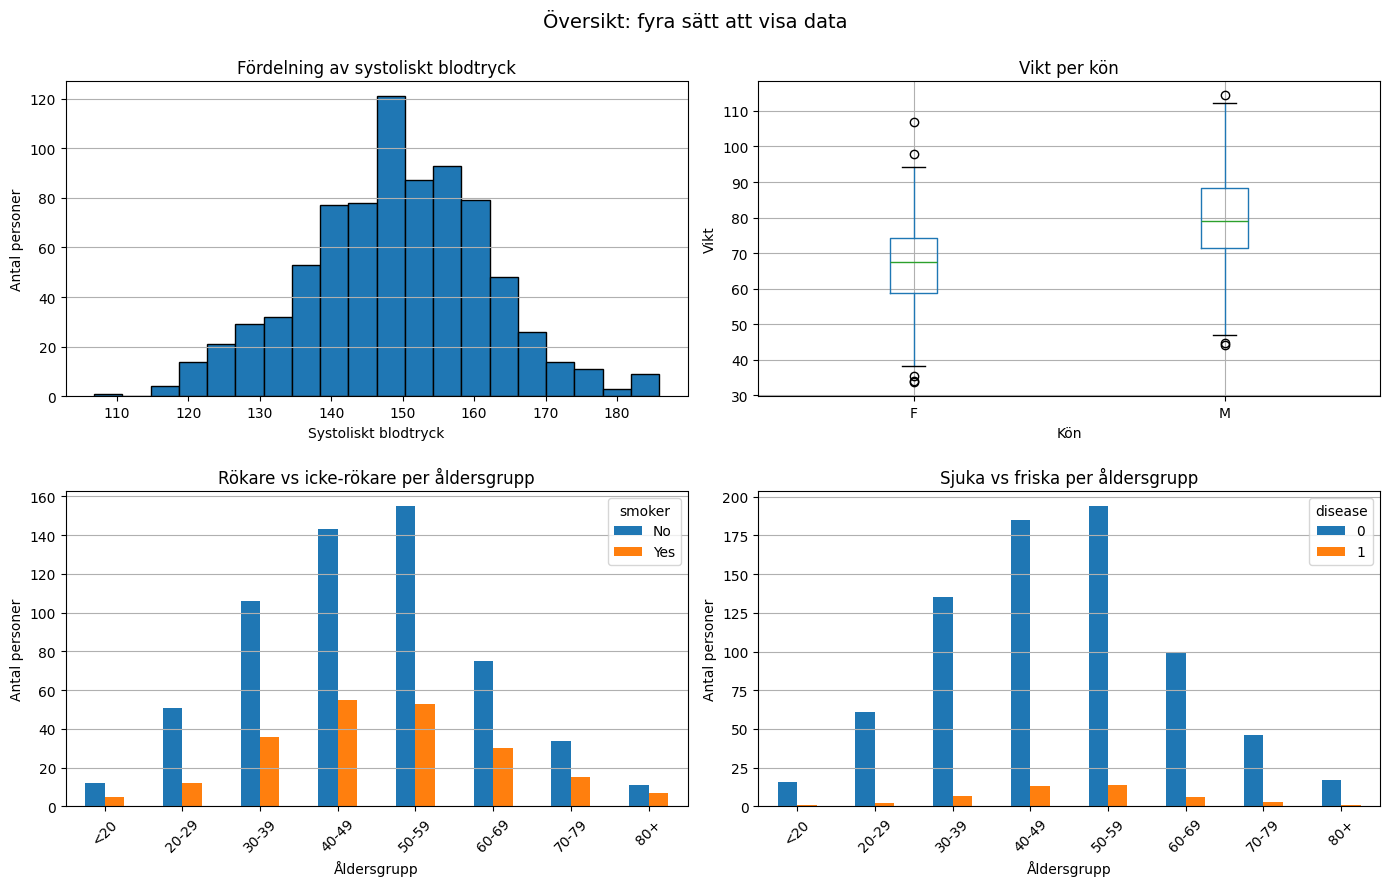

In [33]:
fig, axes = V.overview_grid(df_clean)
plt.show()

### Analys av andel sjuka vs icke sjuka  
Beräkning av andelen personer i datasetet som har sjukdomen och jämför med en simulering.  
Jämför observerad och simulerad andel med 95% konfidensintervall.  
Visualisering av jämförelsen.

Andel observerat sjuka: 5.9%
Andel simulerat sjuka: 5.6%


,grupp,n,andel,ci_low,ci_high
0,Observerat,800,0.059,0.042,0.075
1,Simulerat,1000,0.067,0.052,0.082


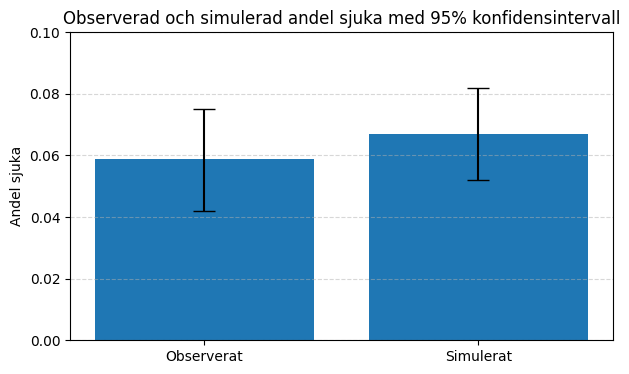

In [34]:
HA = HealthAnalyzer(df_clean)

p_obs = HA.observed()
print(f"Andel observerat sjuka: {p_obs*100:.1f}%")

p_sim = HA.simulated()
print(f"Andel simulerat sjuka: {p_sim*100:.1f}%")

summary_compare = HA.compare()
display(summary_compare)

HA.plot_compare(summary_compare)
plt.show()

#### Slutsats  
En simulering baserad på samma sannolikhet som den observerade visar att deras respektive konfidensintervall överlappar tydligt.  
Detta innebär att de inte skiljer sig statistiskt vilket indikerar att den observerade andelen sjuka kan vara representativ för populationen.

### Konfidensintervall för medelvärdet av systoliskt blodtryck
Beräkning av konfidensintervall för medelvärdet av systolic_bp med normalapproximation och bootstrap.  
Visualisering av jämförelsen.

Normal medelvärde: 149.178625
Normal 95% konfidensintervall: [148.29, 150.07]

Bootstrap medelvärde: 149.178625
Bootstrap 95% KI: [148.33, 150.07]


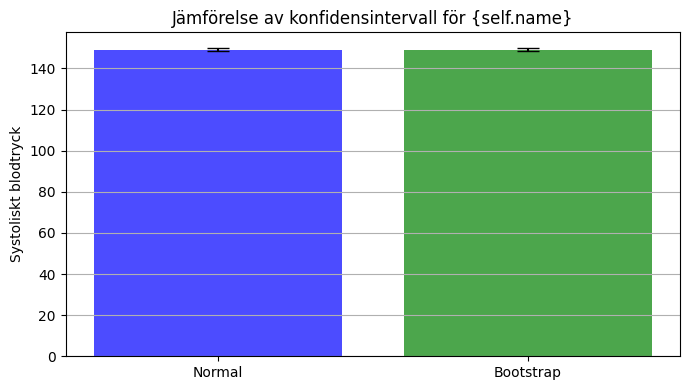

In [35]:
MA = MeanCIAnalyzer(df_clean["systolic_bp"], name="Systoliskt blodtryck")
nlo, nhi, nmean, s, n = MA.ci_mean_normal()
print(f"Normal medelvärde: {nmean:.6f}")
print(f"Normal 95% konfidensintervall: [{nlo:.2f}, {nhi:.2f}]")

blo, bhi, bmean = MA.ci_mean_bootstrap(B=5000)
print(f"\nBootstrap medelvärde: {bmean:.6f}")
print(f"Bootstrap 95% KI: [{blo:.2f}, {bhi:.2f}]")

MA.plot_compare(nlo, nhi, nmean, blo, bhi, bmean)
plt.show()

#### Slutsats  
Medelvärdet och konfidensintervallet med normalapproximation och Bootstrap är mycket lika vilket indikerar att data för systoliskt blodtryck är normalfördelad.  
Detta innebär t-test kan användas för att jämföra medelvärden mellan grupper.

### Hypotesprövning och powersimuleringar  
H₀: Rökare och icke-rökares medel-blodtryck skiljer sig inte åt.  
H₁: Rökare har högre medel-blodtryck än icke-rökare.

T-test valdes för att jämför medelvärden, både standard och Welch.  
Effekten studerades med Cohen's d.  

Beräkning av simulerad och analytisk power.  
Beräkning av storleken på urval för att uppnå 80% power.  
Visualisering av urval vs power. 

Power simulerades och visualiserades även för medelvärde av kolesterol och ålder för grupperna rökare vs icke-rökare.

Medelvärden (systolic_bp):
Rökare: 149.52 ± 13.24
Icke-rökare: 149.05 ± 12.62

T-testresultat:
Standard t-test: t = -0.461, p = 0.6450
Welch t-test: t = -0.450, p = 0.6527
Cohen's d: 0.0369
Power (simulerad) i hypotestestet ≈ 7.2%
Power (analytisk) i hypotestestet: 7.5%
N som krävs i gruppen icke rökare för 80% power: 21690 (rökare ≈ 7871)


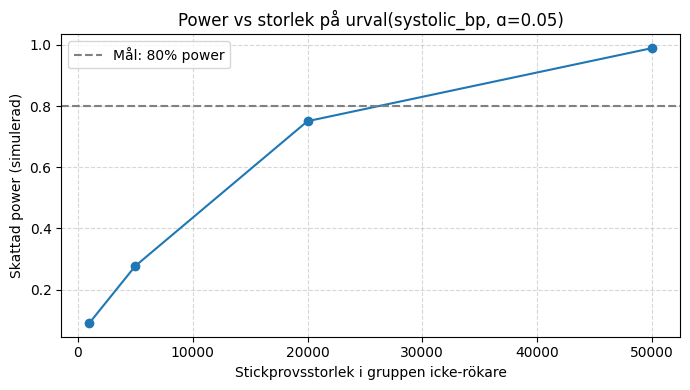

In [36]:
SA = SmokerAnalyzer(df_clean)

print(f"Medelvärden ({SA.value_col}):")
print(f"Rökare: {SA.mean_rökare:.2f} ± {SA.std_rökare:.2f}")
print(f"Icke-rökare: {SA.mean_ickerökare:.2f} ± {SA.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = SA.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = SA.cohens_d()
print(f"Cohen's d: {d:.4f}")

SA.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {SA.power_sim*100:.1f}%")

SA.power_analytical()
print(f"Power (analytisk) i hypotestestet: {SA.power_ana*100:.1f}%")

SA.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(SA.n_needed):.0f} (rökare ≈ {np.ceil(SA.n_needed*SA.ratio):.0f})")

fig, ax = SA.plot_sample_size_power()
plt.show()

Medelvärden (cholesterol):
Rökare: 4.95 ± 0.83
Icke-rökare: 4.92 ± 0.86

T-testresultat:
Standard t-test: t = -0.325, p = 0.7451
Welch t-test: t = -0.330, p = 0.7413
Cohen's d: 0.0260
Power (simulerad) i hypotestestet ≈ 6.5%
Power (analytisk) i hypotestestet: 6.2%
N som krävs i gruppen icke rökare för 80% power: 43570 (rökare ≈ 15810)


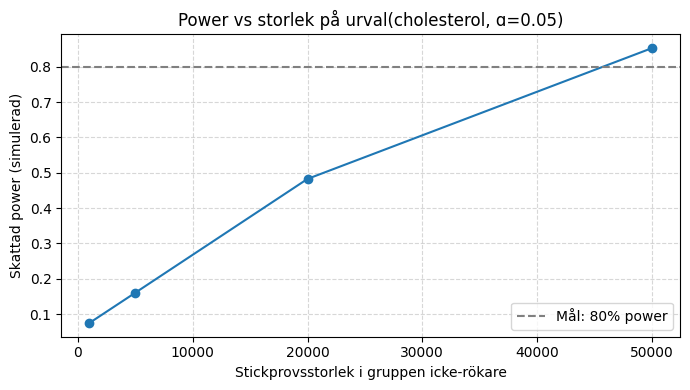

In [38]:
SA = SmokerAnalyzer(df_clean, value_col="cholesterol")

print(f"Medelvärden ({SA.value_col}):")
print(f"Rökare: {SA.mean_rökare:.2f} ± {SA.std_rökare:.2f}")
print(f"Icke-rökare: {SA.mean_ickerökare:.2f} ± {SA.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = SA.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = SA.cohens_d()
print(f"Cohen's d: {d:.4f}")

SA.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {SA.power_sim*100:.1f}%")

SA.power_analytical()
print(f"Power (analytisk) i hypotestestet: {SA.power_ana*100:.1f}%")

SA.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(SA.n_needed):.0f} (rökare ≈ {np.ceil(SA.n_needed*SA.ratio):.0f})")

fig, ax = SA.plot_sample_size_power()
plt.show()

Medelvärden (age):
Rökare: 50.42 ± 14.60
Icke-rökare: 49.06 ± 14.44

T-testresultat:
Standard t-test: t = -1.171, p = 0.2420
Welch t-test: t = -1.164, p = 0.2452
Cohen's d: 0.0937
Power (simulerad) i hypotestestet ≈ 22.4%
Power (analytisk) i hypotestestet: 21.5%
N som krävs i gruppen icke rökare för 80% power: 3363 (rökare ≈ 1221)


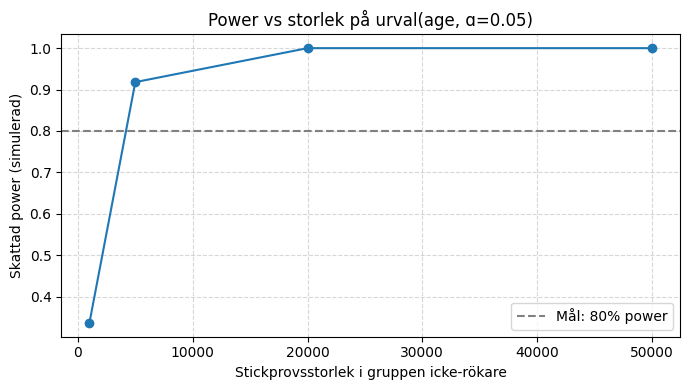

In [39]:
SA = SmokerAnalyzer(df_clean, value_col="age")

print(f"Medelvärden ({SA.value_col}):")
print(f"Rökare: {SA.mean_rökare:.2f} ± {SA.std_rökare:.2f}")
print(f"Icke-rökare: {SA.mean_ickerökare:.2f} ± {SA.std_ickerökare:.2f}\n")

t_stat, p_val, t_stat_w, p_val_w = SA.ttests()
print("T-testresultat:")
print(f"Standard t-test: t = {t_stat:.3f}, p = {p_val:.4f}") 
print(f"Welch t-test: t = {t_stat_w:.3f}, p = {p_val_w:.4f}")

d = SA.cohens_d()
print(f"Cohen's d: {d:.4f}")

SA.power_simulation()
print(f"Power (simulerad) i hypotestestet ≈ {SA.power_sim*100:.1f}%")

SA.power_analytical()
print(f"Power (analytisk) i hypotestestet: {SA.power_ana*100:.1f}%")

SA.power_n_required()
print(f"N som krävs i gruppen icke rökare för 80% power: {np.ceil(SA.n_needed):.0f} (rökare ≈ {np.ceil(SA.n_needed*SA.ratio):.0f})")

fig, ax = SA.plot_sample_size_power()
plt.show()

#### Slutsats avseende hypotestest 
**T-test**   
T-testen visar att det inte finns någon signifikant skillnad mellan medelvärdet av systoliskt blodtryck mellan gruppen rökare och icke-rökare.  
Både t-test och Welch-test visar liknande resultat vilket stödjer detta. p > 0,05 så nollhypotesen kan inte förkastas.  

**Cohen's d**  
Cohen's d är under 0,2 vilket visar på en liten effekt och stödjer t-testets resultat att det inte är en signifikant skillnad mellan gruppernas medelvärden.
D är positivt vilket indikerar att rökare har ett högre systoliskt blodtryck än icke-rökare. Då skillnaden inte är signifikant och effekten liten så går det inte att säga utifrån datan att rökning har en påverkan på systoliskt blodtryck.
  
**Power**  
Power (simulerad) i hypotestestet är låg och vilket indikerar att hypotestestet inte är så säkert.  
Effektstorleken (Cohen's d) är litet vilket i kombnination med stoleken på urval, totalt 800, ger en låg power.  
Den analytiska beräkningen av storleken på urval visar att med den effekt som observerats så skulle urvalet behöva vara ca 30 000 för att uppnå en power på 80%.  

##### Kommentar angående kolesterol och ålder

-----Enkel linjär regression: systoliskt blodtryck vid ålder-----

Skärningspunkt: 122.685
Lutning: ŷ = 0.5360
Förklaringsgrad (R²): 0.369

Predikterat systoliskt blodtryck vid 40 års ålder: 144.13 mmHg
Predikterat systoliskt blodtryck vid 60 års ålder: 154.85 mmHg
Predikterat systoliskt blodtryck vid 80 års ålder: 165.57 mmHg


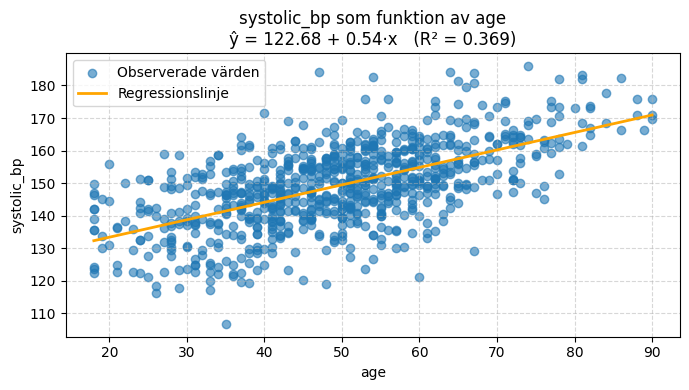

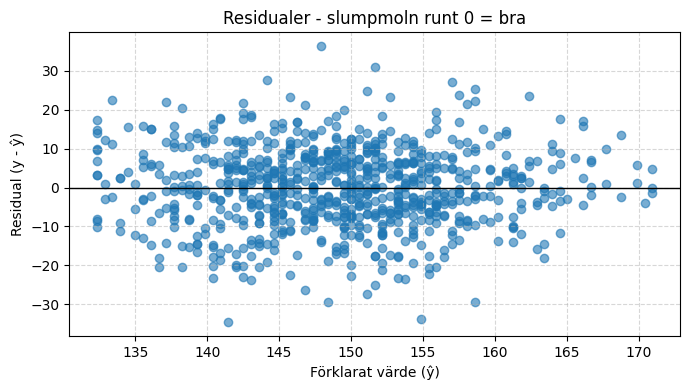

In [40]:
BP1 = BPAnalyzer1(df_clean, x_col="age", y_col="systolic_bp")

print("-----Enkel linjär regression: systoliskt blodtryck vid ålder-----\n")
print(f"Skärningspunkt: {BP1.intercept:.3f}")
print(f"Lutning: ŷ = {BP1.slope:.4f}")
print(f"Förklaringsgrad (R²): {BP1.r2:.3f}\n")

ages = [40, 60, 80]
for age in ages:
    pred = BP1.prediction([age])[0]
    print(f"Predikterat systoliskt blodtryck vid {age} års ålder: {pred:.2f} mmHg")

fig, ax = BP1.plot_model()
plt.show()

fig, ax = BP1.plot_residuals()
plt.show()

-----Multipel linjär regression: systoliskt blodtryck vid ålder och vikt-----

Skärningspunkt: 109.499
Lutning ålder: 0.5389
Lutning vikt: 0.1777
Förklaringsgrad (R²): 0.405

Predikterat systoliskt blodtryck vid 70 kg och 40 år: 143.49 mmHg
Predikterat systoliskt blodtryck vid 70 kg och 60 år: 154.27 mmHg
Predikterat systoliskt blodtryck vid 70 kg och 80 år: 165.05 mmHg

Predikterat systoliskt blodtryck vid 90 kg och 40 år: 147.05 mmHg
Predikterat systoliskt blodtryck vid 90 kg och 60 år: 157.82 mmHg
Predikterat systoliskt blodtryck vid 90 kg och 80 år: 168.60 mmHg


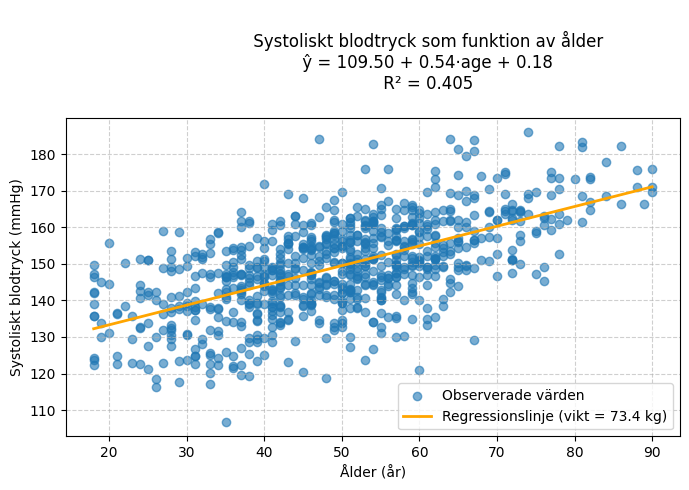

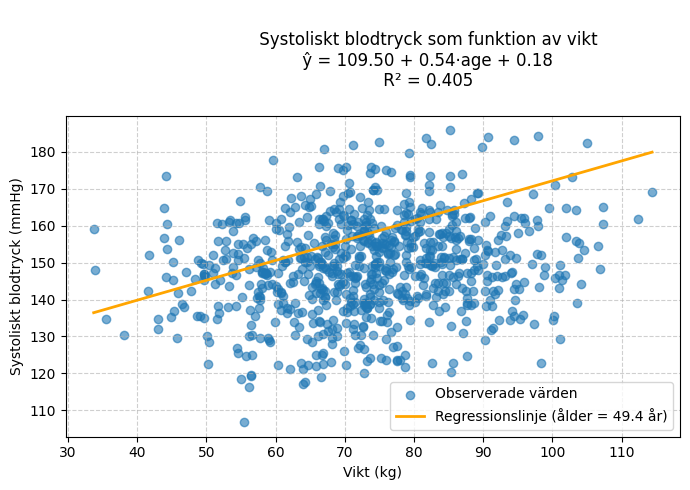

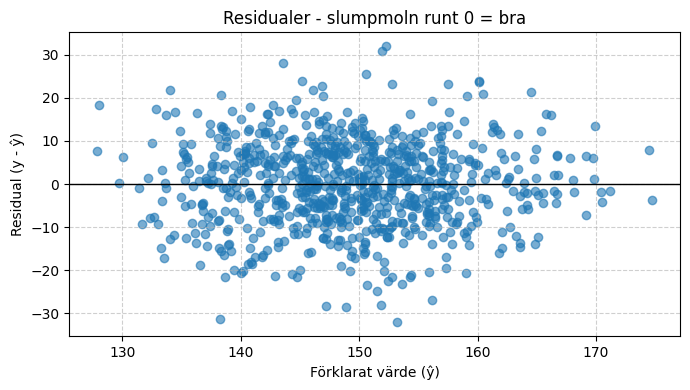

In [41]:
BP2 = BPAnalyzer2(df_clean)

print("-----Multipel linjär regression: systoliskt blodtryck vid ålder och vikt-----\n")
print(f"Skärningspunkt: {BP2.intercept:.3f}")
print(f"Lutning ålder: {BP2.slope_age:.4f}")
print(f"Lutning vikt: {BP2.slope_weight:.4f}")
print(f"Förklaringsgrad (R²): {BP2.r2:.3f}\n")

weight = 70
ages = [40, 60, 80]
for age in ages:
    pred = BP2.prediction(age=age, weight=weight)[0]
    print(f"Predikterat systoliskt blodtryck vid {weight} kg och {age} år: {pred:.2f} mmHg")
print()
weight = 90
ages = [40, 60, 80]
for age in ages:
    pred = BP2.prediction(age=age, weight=weight)[0]
    print(f"Predikterat systoliskt blodtryck vid {weight} kg och {age} år: {pred:.2f} mmHg")

fig, ax = BP2.plot_model_age()
plt.show()

fig, ax = BP2.plot_model_weight()
plt.show()

fig, ax = BP2.plot_residuals()
plt.show()

### PCA
https://www.geeksforgeeks.org/data-analysis/principal-component-analysis-pca/

In [ ]:
X_pca, pca_model = M.pc_analysis(df_clean)

print("Förklarad varians (HK1 & HK2):", pca_model.explained_variance_ratio_)

fig, ax = V.plot_pca_scatter(X_pca, df_clean["sex"])
ax.set_title("PCA: färgkodad efter kön (K/M)")
ax.collections[-1].colorbar.set_label("Grupp (kön)")
codes, levels = pd.factorize(df_clean["sex"])
ax.text(
    0.02, 0.95,
    f"Blå = {levels[0]}\nRöd = {levels[1]}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)
plt.show()

fig, ax = V.plot_pca_scatter(X_pca, df_clean["smoker"])
ax.set_title("PCA: färgkodad efter rökare (Ja/Nej)")
ax.collections[-1].colorbar.set_label("Grupp (rökare)")
codes, levels = pd.factorize(df_clean["smoker"])
ax.text(
    0.02, 0.95,
    f"Blå = {levels[0]}\nRöd = {levels[1]}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)
plt.show()

fig, ax = V.plot_pca_scatter(X_pca, df_clean["disease"])
ax.set_title("PCA: färgkodad efter sjukdom (0/1)")
ax.collections[-1].colorbar.set_label("Grupp (sjukdom)")
codes, levels = pd.factorize(df_clean["disease"])
ax.text(
    0.02, 0.95,
    f"Blå = {levels[0]}\nRöd = {levels[1]}",
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)
plt.show()

In [ ]:
cm, acc, pca_model, logreg_model, X_pca, y = M.pc_analysis_ML(df_clean)

print("Förklarad varians (HK1 & HK2):", pca_model.explained_variance_ratio_)
print(f"Nogrannhet (accuracy): {acc:.3f}")

V.plot_confusion_matrix(cm)
plt.show()

V.plot_pca_scatter(X_pca, y)
plt.show()
